# **<font color="red">Lasso Regression</font>**

R2_Score:  0.7537
Coef_:  [27.93334735]
Intercept_:  -3.1515719898009404


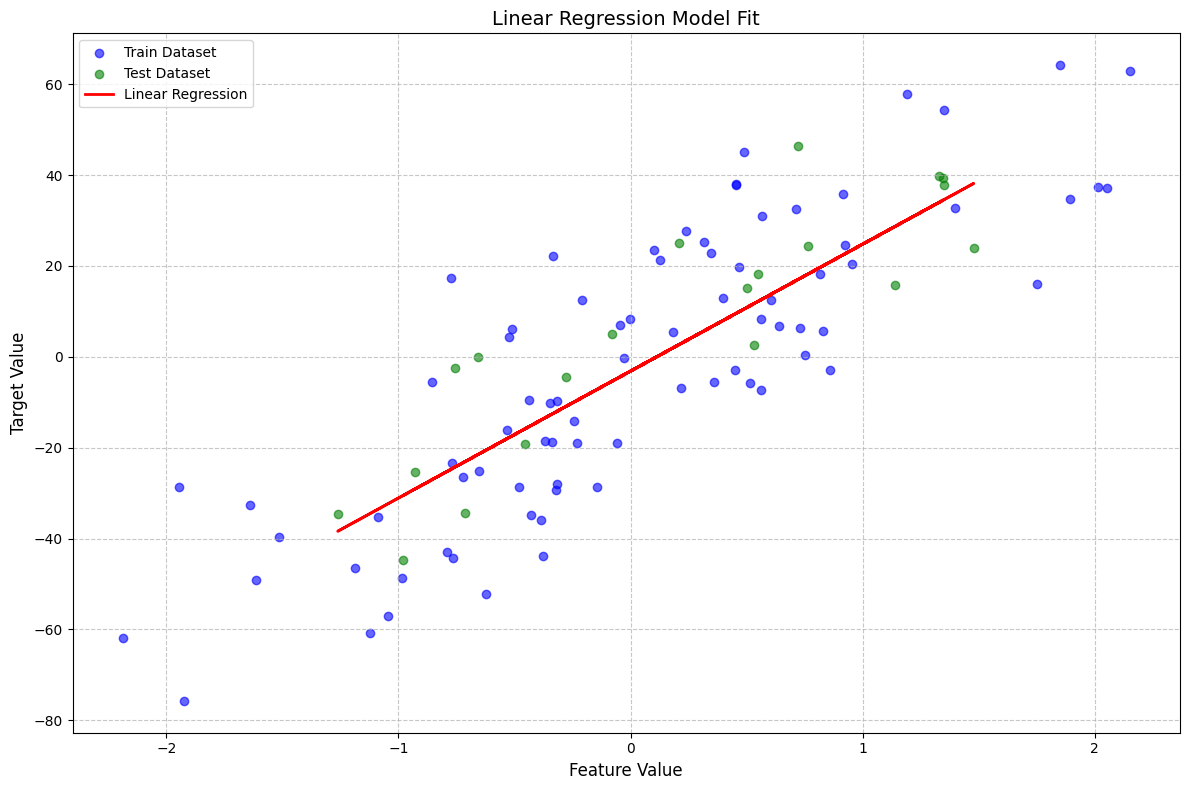

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Lasso
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression
from sklearn.metrics import r2_score

X, y = make_regression(n_samples=100,
                       n_features=1, 
                       n_informative=1,
                       n_targets=1,
                       noise=20,
                       random_state=13)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=22)
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
r2_score = r2_score(y_test, y_pred)
print("R2_Score: ", round(r2_score, 4))

print("Coef_: ", lr.coef_)
print("Intercept_: ", lr.intercept_)

# Plots
plt.figure(figsize=(12, 8))
plt.scatter(X_train.ravel(), y_train, color="blue", alpha=0.6, label="Train Dataset")
plt.scatter(X_test.ravel(), y_test, color="green", alpha=0.6, label="Test Dataset")
plt.plot(X_test.ravel(), y_pred, color="red", linewidth=2, label="Linear Regression")

# Label axes with proper text (not arrays)
plt.xlabel("Feature Value", fontsize=12)
plt.ylabel("Target Value", fontsize=12)

plt.title("Linear Regression Model Fit", fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

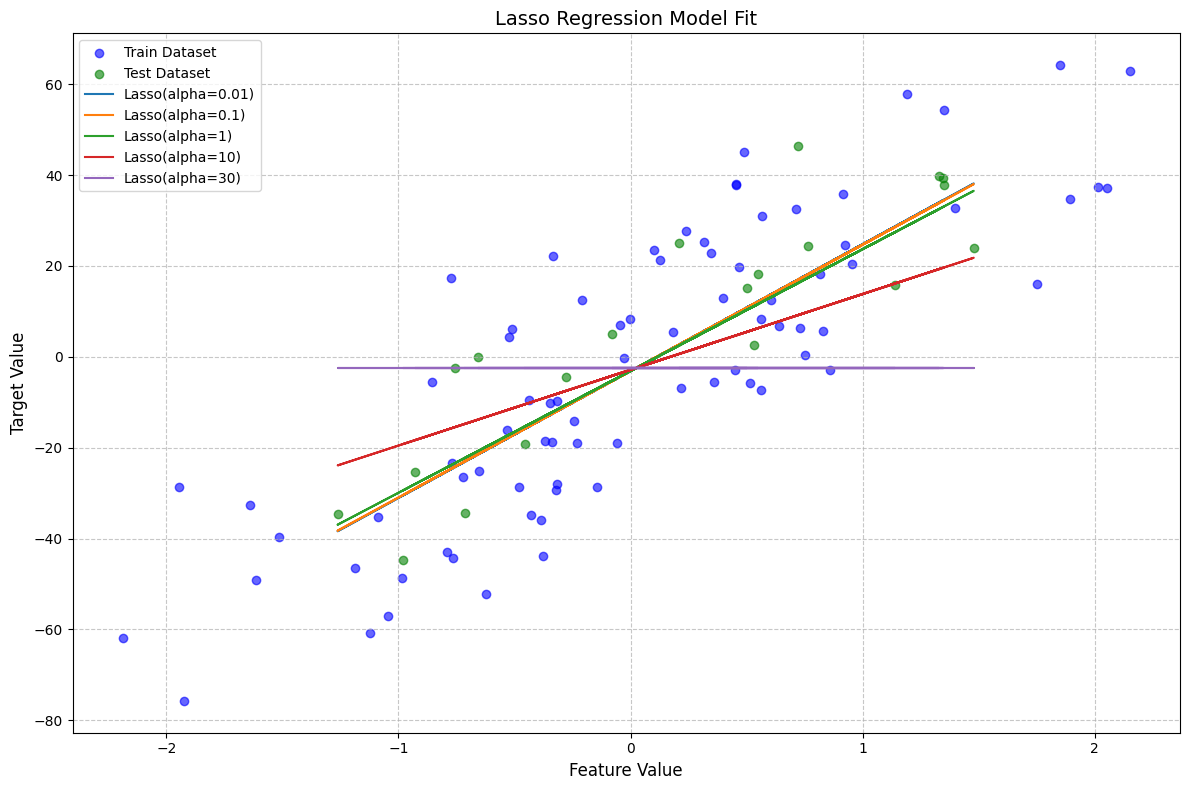

In [2]:
alphas = [0.01, 0.1, 1, 10, 30]
plt.figure(figsize=(12, 8))
plt.scatter(X_train.ravel(), y_train, color="blue", alpha=0.6, label="Train Dataset")
plt.scatter(X_test.ravel(), y_test, color="green", alpha=0.6, label="Test Dataset")
for alpha in alphas:
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train, y_train)
    y_pred = lasso.predict(X_test)
    plt.plot(X_test.ravel(), y_pred, label=f"Lasso(alpha={alpha})")
    
# Label axes with proper text (not arrays)
plt.xlabel("Feature Value", fontsize=12)
plt.ylabel("Target Value", fontsize=12)

plt.title("Lasso Regression Model Fit", fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## **<font color="green">Lasso Regression on Polynomial Dataset</font>**

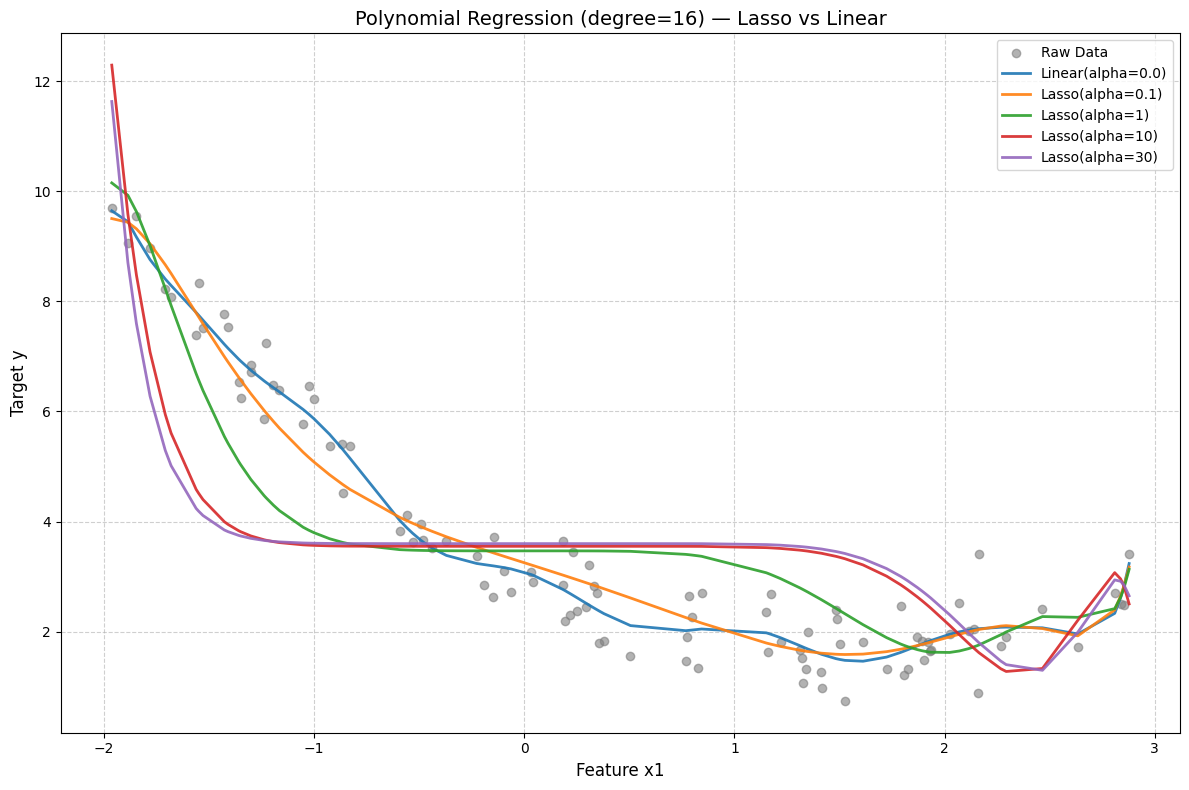

In [6]:
# polynomial_lasso_fit.py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Lasso, LinearRegression
import warnings

# ------------------------
# Data generation (reproducible)
# ------------------------
rng = np.random.default_rng(42)
m = 100
x1 = 5 * rng.random((m, 1)) - 2            # shape (m,1)
# underlying non-linear relation with noise
x2 = 0.7 * x1**2 - 2 * x1 + 3 + rng.standard_normal((m, 1)) * 0.5

# Flatten target to 1D (scikit-learn expects y to be 1D for regression)
y = x2.ravel()

# ------------------------
# Utility: fit and predict using a pipeline
# ------------------------
def get_model_and_pred(x, y, degree=16, alpha=1.0, max_iter=20000):
    """
    If alpha == 0 -> use LinearRegression (no L1 penalty).
    Else -> use Lasso with given alpha.
    Returns: fitted_model, y_pred (aligned with input x)
    """
    if alpha == 0:
        base_estimator = LinearRegression()
    else:
        base_estimator = Lasso(alpha=alpha, max_iter=max_iter)
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("est", base_estimator),
    ])
    # Fit
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")  # suppress Lasso convergence warnings (we increase max_iter)
        model.fit(x, y)
    # Predict
    y_pred = model.predict(x)
    return model, y_pred

# ------------------------
# Plotting
# ------------------------
alphas = [0.0, 0.1, 1, 10, 30]                 # alpha==0 -> plain LinearRegression
colors = ['red', 'green', 'blue', 'purple', 'magenta']
degrees = 16                                    # keep degree=16 as in your original; lower if you want

plt.figure(figsize=(12, 8))
plt.scatter(x1, y, color='gray', alpha=0.6, label="Raw Data")

# For smooth curve plotting, sort x before plotting model predictions
sort_idx = np.argsort(x1.ravel())
x1_sorted = x1.ravel()[sort_idx].reshape(-1, 1)

for alpha, color in zip(alphas, colors):
    model, _ = get_model_and_pred(x1, y, degree=degrees, alpha=alpha)
    y_pred_sorted = model.predict(x1_sorted)
    label = f"{'Linear' if alpha==0 else 'Lasso'}(alpha={alpha})"
    plt.plot(x1_sorted, y_pred_sorted, label=label, linewidth=2, alpha=0.9)

plt.xlabel("Feature x1", fontsize=12)
plt.ylabel("Target y", fontsize=12)
plt.title(f"Polynomial Regression (degree={degrees}) — Lasso vs Linear", fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
